In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
import scipy.stats as stats

In [39]:
df= pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0
1,female,group C,some college,standard,completed,69.0,90.0,88.0
2,female,group B,master's degree,standard,none,90.0,95.0,93.0
3,male,group A,associate's degree,free/reduced,none,47.0,57.0,NaN
4,male,group C,some college,standard,none,76.0,78.0,75.0


In [40]:
df.info()
df.describe()
df.columns



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   994 non-null    float64
 6   reading score                994 non-null    float64
 7   writing score                997 non-null    float64
dtypes: float64(3), object(5)
memory usage: 62.6+ KB


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [41]:
df.shape

(1000, 8)

In [42]:
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,float64
reading score,float64
writing score,float64


In [43]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,6
reading score,6
writing score,3


In [44]:
outliers=[]
def detect(df):
  threshold=3
  mean=np.mean(df)
  std=np.std(df)
  for d in df:
    z_score=(d-mean)/std
    if np.abs(z_score)>threshold:
      outliers.append(d)
  return outliers

In [45]:
var='math score'

In [46]:
z_scores=detect(df[var])

In [47]:
outliers=df[df[var].isin(z_scores)]

In [48]:
outliers

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
7,male,group B,some college,free/reduced,none,120.0,43.0,39.0
17,female,group B,some high school,free/reduced,none,18.0,32.0,28.0
39,male,group B,associate's degree,free/reduced,none,10.0,56.0,57.0
59,female,group C,some high school,free/reduced,none,0.0,17.0,10.0
113,female,group D,some college,standard,none,1.0,58.0,54.0
139,male,group D,some college,standard,completed,200.0,61.0,69.0
980,female,group B,high school,free/reduced,none,8.0,24.0,23.0


In [49]:
score_cols = ["math score","reading score","writing score"]
score_cols = ["math score","reading score","writing score"]

for col in score_cols:
  df.loc[df[col]>100, col] = 100
  df.loc[df[col] < 0 ,col] = 0

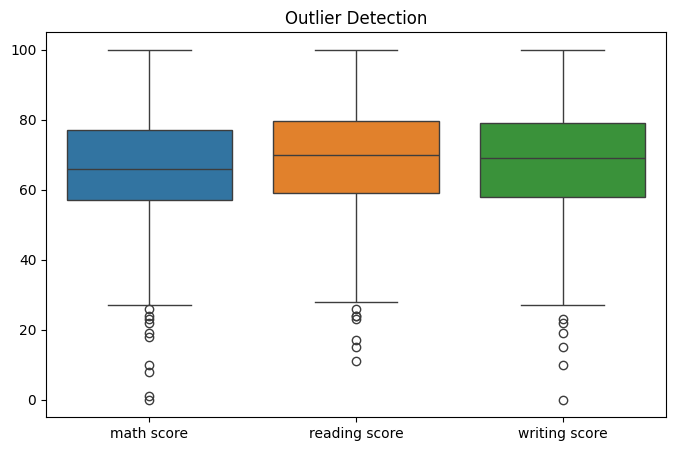

In [50]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[score_cols])
plt.title("Outlier Detection")
plt.show()

In [51]:
from numpy._core.defchararray import upper
from re import I
def treat_outliers(col):
  Q1=df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR=Q3-Q1

  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR

  df[col]=np.where(df[col]>upper,upper,np.where(df[col]<lower,lower,df[col]))

for col in score_cols:
  treat_outliers(col)

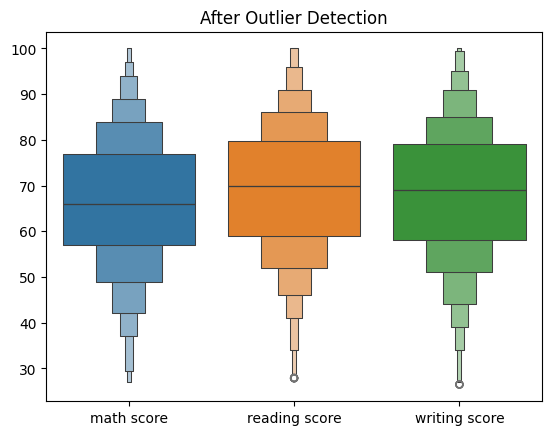

In [52]:
sns.boxenplot(data=df[score_cols])
plt.title("After Outlier Detection")
plt.show()

In [53]:
df.describe()

,math score,reading score,writing score
count,994.000000,994.000000,997.000000
mean,66.229376,69.191273,68.130391
std,15.081174,14.690582,15.119124
min,27.000000,27.875000,26.500000
25%,57.000000,59.000000,58.000000
50%,66.000000,70.000000,69.000000
75%,77.000000,79.750000,79.000000
max,100.000000,100.000000,100.000000


In [54]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0
1,female,group C,some college,standard,completed,69.0,90.0,88.0
2,female,group B,master's degree,standard,none,90.0,95.0,93.0
3,male,group A,associate's degree,free/reduced,none,47.0,57.0,NaN
4,male,group C,some college,standard,none,76.0,78.0,75.0


In [55]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88.0,99.0,95.0
996,male,group C,high school,free/reduced,none,62.0,55.0,55.0
997,female,group C,high school,free/reduced,completed,59.0,71.0,65.0
998,female,group D,some college,standard,completed,68.0,78.0,77.0
999,female,group D,some college,free/reduced,none,77.0,86.0,86.0


In [56]:
df.shape

(1000, 8)

In [57]:
df.columns


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [58]:
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,float64
reading score,float64
writing score,float64


In [59]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,6
reading score,6
writing score,3


In [60]:
df2=df.fillna(0)

In [62]:
df2


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0
1,female,group C,some college,standard,completed,69.0,90.0,88.0
2,female,group B,master's degree,standard,none,90.0,95.0,93.0
3,male,group A,associate's degree,free/reduced,none,47.0,57.0,0.0
4,male,group C,some college,standard,none,76.0,78.0,75.0
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88.0,99.0,95.0
996,male,group C,high school,free/reduced,none,62.0,55.0,55.0
997,female,group C,high school,free/reduced,completed,59.0,71.0,65.0
998,female,group D,some college,standard,completed,68.0,78.0,77.0


In [63]:
df3=df.dropna()

In [64]:
df3

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0
1,female,group C,some college,standard,completed,69.0,90.0,88.0
2,female,group B,master's degree,standard,none,90.0,95.0,93.0
4,male,group C,some college,standard,none,76.0,78.0,75.0
5,female,group B,associate's degree,standard,none,71.0,83.0,78.0
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88.0,99.0,95.0
996,male,group C,high school,free/reduced,none,62.0,55.0,55.0
997,female,group C,high school,free/reduced,completed,59.0,71.0,65.0
998,female,group D,some college,standard,completed,68.0,78.0,77.0


In [65]:
df2.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,float64
reading score,float64
writing score,float64


In [66]:
df2=df2.astype({"math score":"int"})

In [69]:
df2.dtypes


,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,float64
writing score,float64


In [70]:
norm=stats.zscore(df2['math score'])

In [77]:
norm

array([ 0.38853994,  0.19956137,  1.52241137, -1.18628148,  0.64051137,
        0.32554708,  1.39642565,  2.15233994, -0.11540291, -1.7532172 ,
       -0.49336006, -1.62723148, -4.14694576,  0.76649708, -0.99730291,
        0.19956137,  1.39642565, -2.44613862, -1.24927434, -0.74533148,
        0.0105828 , -0.05241006, -1.37526005,  0.19956137,  0.51452566,
        0.4515328 ,  0.19956137,  0.07357566,  0.26255423, -0.24138863,
        0.19956137, -0.17839577, -0.61934577, -1.62723148,  1.96336137,
        0.95547565,  0.51452566, -0.99730291,  0.57751851, -2.44613862,
       -0.68233863, -0.49336006, -0.80832434, -0.4303672 , -0.99730291,
       -0.05241006, -0.68233863,  0.0105828 , -0.55635291,  1.01846851,
       -0.80832434,  0.70350423, -0.80832434,  1.39642565,  0.32554708,
       -2.06818148,  1.01846851, -0.8713172 , -0.49336006, -2.44613862,
        0.82948994, -1.69022434, -0.24138863,  0.19956137, -0.4303672 ,
        0.07357566, -1.3122672 , -0.36737434, -0.30438148, -1.69

In [78]:
dm=pd.get_dummies(df['gender'])

In [79]:
dm

,female,male
0,True,False
1,True,False
2,True,False
3,False,True
4,False,True
...,...,...
995,True,False
996,False,True
997,True,False
998,True,False
